In [14]:
import yfinance as yf

data = yf.download ("SPY", start = "2025-01-01", end = "2026-01-01")
data = data.droplevel ('Ticker', axis=1)
data['daily_return'] = data['Close'].pct_change()
print("SPY shape:", data.shape)
print(data['daily_return'].tail(3))
data_max = data['daily_return'].idxmax()
print (data_max.date())


[*********************100%***********************]  1 of 1 completed

SPY shape: (250, 6)
2025-12-29   -0.003564
2025-12-30   -0.001221
2025-12-31   -0.007409
Name: daily_return, dtype: float64
2025-04-09


In [12]:
sti = yf.download("ES3.SI", start = "2025-01-01", end = "2026-01-01")
sti = sti.droplevel ('Ticker', axis = 1)
sti['daily_return'] = sti['Close'].pct_change()
print("STI shape:", sti.shape)
print(sti['daily_return'].tail(3))
sti_max = sti['daily_return'].idxmax()
print(sti_max.date())

[*********************100%***********************]  1 of 1 completed

STI shape: (251, 6)
2025-12-29    0.001910
2025-12-30    0.005085
2025-12-31   -0.004848
Name: daily_return, dtype: float64
2025-04-10


In [25]:
import pandas as pd

combined = pd.DataFrame({
    'SPY': data['daily_return'],
    'STI': sti['daily_return']
}).dropna()

print(combined.shape)
print(combined.head())
print(combined.loc["2025-04-01" : "2025-04-10"])

(242, 2)
                 SPY       STI
2025-01-03  0.012503  0.002320
2025-01-06  0.005761  0.000514
2025-01-07 -0.011304  0.002313
2025-01-08  0.001461  0.018462
2025-01-10 -0.015267 -0.010706
                 SPY       STI
2025-04-01  0.002824 -0.003514
2025-04-02  0.006328 -0.002267
2025-04-03 -0.049281 -0.004544
2025-04-04 -0.058543 -0.028405
2025-04-07 -0.001781 -0.073349
2025-04-08 -0.015663 -0.012676
2025-04-09  0.105019 -0.026248
2025-04-10 -0.043819  0.051275


In [26]:
correlation = combined['SPY'].corr(combined['STI'])
print(f"SPY vs STI correlation: {correlation:.4f}")

SPY vs STI correlation: -0.0860


In [31]:
lagged_corr = combined['SPY'].corr(combined['STI'].shift(-1))
print(f"STI vs SPY lagged 1 day correlation: {lagged_corr:.4f}")

STI vs SPY lagged 1 day correlation: 0.6094


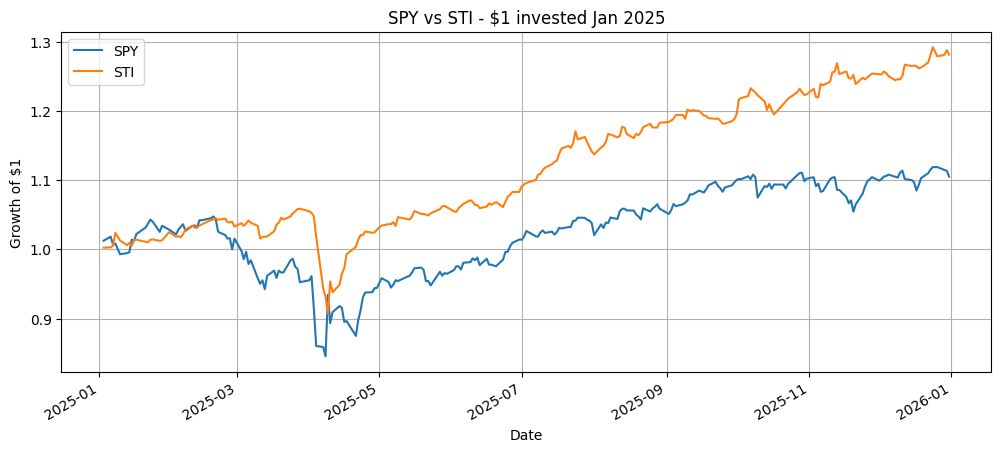

In [32]:
import matplotlib.pyplot as plt

combined_cumulative = (1 + combined).cumprod()
combined_cumulative.plot(figsize=(12,5))
plt.title("SPY vs STI - $1 invested Jan 2025")
plt.ylabel("Growth of $1")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [34]:
spy_sharpe = (combined['SPY'].mean() / combined['SPY'].std()) * (252**0.5)
sti_sharpe = (combined['STI'].mean() / combined['STI'].std()) * (252**0.5)

print(f"SPY Sharpe: {spy_sharpe:.4f}")
print(f"STI Sharpe: {sti_sharpe:.4f}")

SPY Sharpe: 0.6312
STI Sharpe: 1.9645


In [38]:
spy_vol = (combined['SPY'].std() * (252**0.5))
sti_vol = (combined['STI'].std() * (252**0.5))

print(f"SPY Volatility: {spy_vol:.2%}")
print(f"STI Volatility: {sti_vol:.2%}")

SPY Volatility: 19.45%
STI Volatility: 13.63%


In [39]:
spy_mean = (combined['SPY'].mean() * 252)
sti_mean = (combined['STI'].mean() * 252)

print(f"SPY annual return: {spy_mean:.2%}")
print(f"STI annual return: {sti_mean:.2%}")

SPY annual return: 12.28%
STI annual return: 26.77%


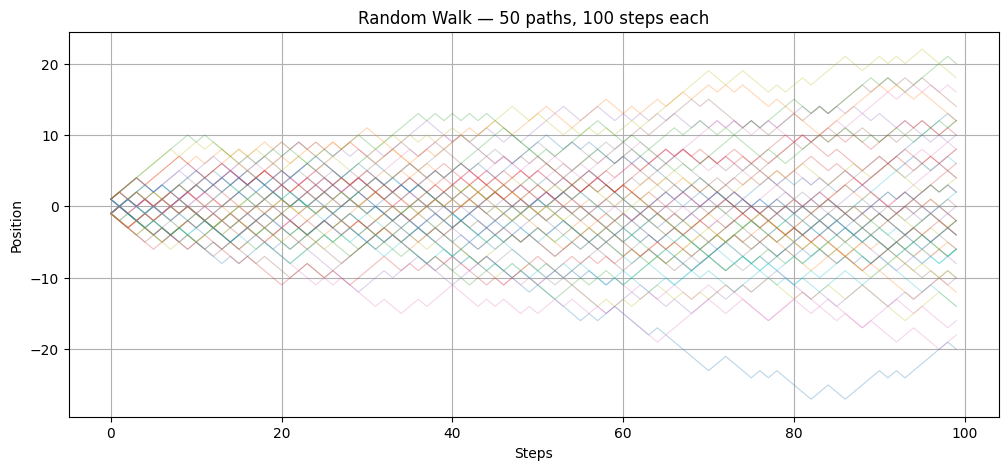

In [40]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
steps = np.random.choice([-1, 1], size=(1000, 100))
paths = steps.cumsum(axis=1)

plt.figure(figsize=(12,5))
plt.plot(paths[:50].T, alpha=0.3, linewidth=0.8)
plt.title("Random Walk — 50 paths, 100 steps each")
plt.xlabel("Steps")
plt.ylabel("Position")
plt.grid(True)
plt.show()